# Нейронные сети и глубокое обучение, МНАД ВШЭ

## Домашнее задание 4. Трансформеры.

### Общая информация

### Оценивание и штрафы

Максимально допустимая оценка за работу без бонусов — 10 баллов. Сдавать задание после указанного срока жесткого дедлайна нельзя.

Сдача работы после мягкого дедлайна штрафуется ступенчато, -1 балл в сутки. Один раз за модуль студентам предоставляется возможность использовать отсрочку и сдать в жесткий дедлайн без штрафа.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Использование генеративных моделей допустимо на следующих условиях:
- Количество кода, написанное генеративными моделями, не превышает 30%
- Указана модель, использованная для генерации, а также промпт
- В конце работы необходимо описать свой опыт использования генеративного ИИ для решения данного домашнего задания. Укажите как часто Вам приходилось исправлять код своими руками или просить модель что-то исправить. Было ли это быстрее, чем написать код самим?

В случае невыполнения этих требований работа не оценивается и оценка за неё не превышает 0 баллов.

### О задании

В этой домашней работе вам предстоит добавить к BERT'у декодерную часть и решить задачу написания tl;dr для текстов новостей на русском языке.

Дополнительно к этому на отличную оценку потребуется реализовать менее жадную стратегию выбора следующего токена для генерации.

In [1]:
# пришлось увеличивать число зависимостей
!pip install transformers datasets evaluate tensorboard rouge-score bert_score

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 8.3 MB/s eta 0:00:00
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=a8031ede4cab949d22b64ea555dc8a1dccd7b6274247a0030a5f602be8c0da76
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


In [2]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, BertModel, BertTokenizer

In [3]:
# варнинги не будут появляться
import warnings
warnings.filterwarnings('ignore')

## Подготовка данных (0.5 балла)

Мы воспользуемся датасетом с 🤗 Ильи Гусева "gazeta". Он представляет собой пары (полный текст новости -- его саммари).

Более подробно про датасет можно прочитать [здесь](https://huggingface.co/datasets/IlyaGusev/gazeta)



In [4]:
# Загрузим данные с попощью библиотеки библиотеки datasets
# Вы вольны взять меньше или больше данных, но что-то около адекватное получается обычно только на >=10%

from datasets import load_dataset

# Нужны обучающая и тестовая выборки, поэтому надо ещё загрузить тестовую выборку
train_dataset = load_dataset("IlyaGusev/gazeta", split="train[:10%]")
test_dataset = load_dataset("IlyaGusev/gazeta", split="test[:10%]")

README.md: 0.00B [00:00, ?B/s]

default/train/0000.parquet:   0%|          | 0.00/252M [00:00<?, ?B/s]

default/train/0001.parquet:   0%|          | 0.00/22.7M [00:00<?, ?B/s]

default/validation/0000.parquet:   0%|          | 0.00/27.8M [00:00<?, ?B/s]

default/test/0000.parquet:   0%|          | 0.00/30.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60964 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/6369 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6793 [00:00<?, ? examples/s]

Вы должны помнить, что тексты перед подачей в модель необходимо **токенизировать**.

Добавьте паддинг до `max_length=512` для обучающих данных, а также до `max_length=128` для меток.

Используйте обрезку текстов, длина которых в токенах превышает `max_length`

In [5]:
# Подготовим данные для модели Bert

model_name = "deepvk/bert-base-uncased"  # Указание модели BERT

tokenizer = AutoTokenizer.from_pretrained(model_name)


def preprocess(examples, use_padding=True):
    # <YOUR CODE HERE>
    if use_padding:
        model_inputs = tokenizer(examples['text'], max_length=512, padding='max_length', truncation=True)
        summary = tokenizer(examples['summary'], max_length=128, padding='max_length', truncation=True)
    else:
        model_inputs = tokenizer(examples['text'])
        summary = tokenizer(examples['summary'])

    model_inputs['labels'] = summary['input_ids']
    return model_inputs

config.json:   0%|          | 0.00/669 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/332 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [6]:
train_tokenized_dataset = train_dataset.map(preprocess, batched=False)
train_tokenized_dataset.set_format("torch")

# Добавлен тестовый датасет
test_tokenized_dataset = test_dataset.map(preprocess, batched=False)
test_tokenized_dataset.set_format("torch")

Map:   0%|          | 0/6096 [00:00<?, ? examples/s]

Map:   0%|          | 0/679 [00:00<?, ? examples/s]

In [7]:
from torch.utils.data import DataLoader
batch_size = 16

train_dataloader = DataLoader(train_tokenized_dataset, shuffle=True, batch_size=batch_size)#<YOUR CODE HERE>
eval_dataloader = DataLoader(test_tokenized_dataset, shuffle=True, batch_size=batch_size)#<YOUR CODE HERE>

## Реализация Decoder-cети (3 балла)

В данном разделе вам необходимо **реализовать собственный декодер для генерации текста**.

Можете вдохновляться кодом с семинара. В инициализации весов стоит (но необязательно) вспомнить нюансы.

In [8]:
import random
import torch
import torch.nn as nn
from transformers import BertModel, BertTokenizer

# Класс модели для суммаризации на основе BERT с кастомным декодером


class BertSummarizer(nn.Module):
    def __init__(
        self,
        bert_model_name="bert-base-uncased",
        hidden_size=768,
        num_decoder_layers=3,
        num_heads=8,
        dropout=0.1,
    ):
        super().__init__()
        self.bert = BertModel.from_pretrained(bert_model_name)
        self.hidden_size = hidden_size

        # Эмбеддинги для токенов на входе в декодер
        self.embedding = nn.Embedding(self.bert.config.vocab_size, hidden_size)

        # <YOUR CODE HERE>
        td_layer = nn.TransformerDecoderLayer(d_model=hidden_size, nhead=num_heads, dropout=dropout)
        self.decoder = nn.TransformerDecoder(decoder_layer=td_layer, num_layers=num_decoder_layers)
        self.fc_out = nn.Linear(hidden_size, self.bert.config.vocab_size)
        self.softmax = nn.Softmax(dim=-1)


    # Функция для создания маски для предотвращения заглядывания вперед в декодере
    def generate_square_subsequent_mask(self, T):
        # <YOUR CODE HERE>
        return torch.full((T, T), float('-inf')).triu(diagonal=1)


    def forward(self, input_ids, attention_mask, decoder_input_ids):
        encoder_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        memory = (
            encoder_outputs.last_hidden_state
        )  # Выходы BERT для использования в декодере

        # Эмбеддинги для входных токенов декодера
        embedded = self.embedding(decoder_input_ids)

        # <YOUR CODE HERE>
        mask = self.generate_square_subsequent_mask(embedded.shape[1])

        decoded = self.decoder(tgt=embedded.transpose(0, 1), memory=memory.transpose(0, 1), tgt_mask=mask)
        output = self.fc_out(decoded.transpose(0, 1)) # change this line

        return output#self.softmax(output) # с softmax не учится


    def generate(self, input_ids, attention_mask, tokenizer, mode='greedy', k=5, p=0.5, max_len=128):
        encoder_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        memory = encoder_outputs.last_hidden_state
        batch_size = input_ids.size(0)

        # Начинаем с токена [CLS] или [BOS] (начало последовательности)
        decoder_input_ids = torch.full(
            (batch_size, 1), tokenizer.cls_token_id, dtype=torch.long
        ).to(input_ids.device)
        memory = memory.transpose(0, 1)
        generated_tokens = []

        for _ in range(max_len):
            embedded = self.embedding(decoder_input_ids).transpose(0, 1)

            # Генерация маски для предотвращения заглядывания вперед
            decoder_attention_mask = self.generate_square_subsequent_mask(
                embedded.size(0)
            ).to(input_ids.device)
            decoder_output = self.decoder(
                tgt=embedded, memory=memory, tgt_mask=decoder_attention_mask
            )

            output = self.fc_out(decoder_output.transpose(0, 1))

            # Получаем индекс токена с наибольшей вероятностью.
            # Помните, если EOS предсказан, прекращаем генерацию

            # <YOUR CODE HERE>
            # генерируем для batch_size = 1
            probs = self.softmax(output[:, -1])

            if 'greedy' == mode:
                token = probs.argmax(dim=-1, keepdim=True)
            elif ('top_k' == mode) or ('topk' == mode):
                indices = probs.argsort(dim=-1, descending=True).squeeze()
                temp_mask = indices < k
                token = random.choice(temp_mask.argwhere()).unsqueeze(0)
            elif ('top_p' == mode) or ('topp' == mode):
                sorted_probs = probs.sort(descending=True)

                cumulative_probs = sorted_probs.values.cumsum(dim=-1)
                cumulative_probs = cumulative_probs[cumulative_probs < p]


                # Если у наибольшая вероятность токена больше p, то заканчиваем генерацию (можно выбирать наиболее вероятный токен)
                if len(cumulative_probs) == 0:
                    token = torch.Tensor([[tokenizer.sep_token_id]]).to(int).to(input_ids.device)
                else:
                    count = cumulative_probs[cumulative_probs < p].argmax(dim=-1)
                    token = random.choice(sorted_probs.indices[0, :count+1]).unsqueeze(0).unsqueeze(0)
            else:
                raise Exception('Неверный режим генерации')
            decoder_input_ids = torch.cat([decoder_input_ids, token], dim=-1)

            # в токенайзере нет eos_token_id
            if token.item() == tokenizer.sep_token_id:
                break

        generated_sequence = tokenizer.decode(
            decoder_input_ids.squeeze().tolist(), skip_special_tokens=True
        )

        return generated_sequence


    def beam_search(self, input_ids, attention_mask, tokenizer, k=3, max_len=128):
        # Только для первой последовательности в батче
        with torch.no_grad():
            encoder_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
            memory = encoder_outputs.last_hidden_state.squeeze()
            batch_size = input_ids.size(0)

            # Начинаем с токена [CLS] или [BOS] (начало последовательности)
            decoder_input_ids = torch.full(
                (1,), tokenizer.cls_token_id, dtype=torch.long
            ).to(input_ids.device)


            embedded = self.embedding(decoder_input_ids)

            # Генерация маски для предотвращения заглядывания вперед
            decoder_attention_mask = self.generate_square_subsequent_mask(
                embedded.size(0)
            ).to(input_ids.device)

            decoder_output = self.decoder(
                tgt=embedded, memory=memory, tgt_mask=decoder_attention_mask
            )

            output = self.fc_out(decoder_output)[-1].squeeze()
            logprobs = self.softmax(output).log()
            sorted_logprobs = logprobs.sort(descending=True)

            first_tokens = []
            first_logprobs = []
            for j, (token, logprobs) in enumerate(zip(sorted_logprobs.indices[:k].squeeze(),
                                                        sorted_logprobs.values[:k].squeeze())):
                first_tokens.append(token.unsqueeze(0))
                first_logprobs.append(logprobs.unsqueeze(0))


            # Использовались logprobs, потому что вероятности слишком маленькие получаются
            beams = torch.Tensor(first_tokens).to(int).to(input_ids.device).unsqueeze(1)
            beams_logprobs = torch.Tensor(first_logprobs).to(input_ids.device).unsqueeze(1)# можно всё переписать под logprobs

            all_beams = [[] for _ in range(k**2)]
            all_beams_logprobs = torch.Tensor([0 for _ in range(k**2)]).to(input_ids.device)

            for _ in range(1, max_len):
                for beam_num in range(k):
                    # в токенайзере нет eos_token_id
                    # Если последний токен был sep_token_id, то пропускаем этот луч
                    if beams[beam_num, -1].item() == tokenizer.sep_token_id:
                        for j in range(k):
                            pad_token = torch.Tensor([tokenizer.pad_token_id]).to(int).to(input_ids.device)
                            all_beams[beam_num*k + j] = torch.cat([beams[beam_num], pad_token], dim=-1)
                            all_beams_logprobs[beam_num*k + j] = beams_logprobs[beam_num] # не изменяем
                        continue

                    embedded = self.embedding(beams[beam_num])

                    # Генерация маски для предотвращения заглядывания вперед
                    decoder_attention_mask = self.generate_square_subsequent_mask(
                        embedded.size(0)
                    ).to(input_ids.device)

                    decoder_output = self.decoder(
                        tgt=embedded, memory=memory, tgt_mask=decoder_attention_mask
                    )

                    output = self.fc_out(decoder_output)[-1].squeeze()
                    logprobs = self.softmax(output).log()
                    sorted_logprobs = logprobs.sort(descending=True)

                    for j, (token, logprobs) in enumerate(zip(sorted_logprobs.indices[:k].squeeze(),
                                                                sorted_logprobs.values[:k].squeeze())):
                        all_beams[beam_num*k + j] = torch.cat([beams[beam_num], token.unsqueeze(0)], dim=-1)
                        all_beams_logprobs[beam_num*k + j] = beams_logprobs[beam_num] + logprobs


                beams_nums = torch.Tensor(all_beams_logprobs).argsort(descending=True)[:k]
                all_beams = [temp_beam.unsqueeze(0) for temp_beam in all_beams if not isinstance(temp_beam, list)]
                beams = torch.cat(all_beams, dim=0)[beams_nums]
                beams_logprobs = torch.Tensor(all_beams_logprobs)[beams_nums]

                all_beams = [[] for _ in range(k**2)]


        beam = beams[beams_logprobs.argmax()]

        generated_sequence = tokenizer.decode(
            beam.squeeze().tolist(), skip_special_tokens=True
        )

        return generated_sequence

In [9]:
# Инициализируем нашу модель и посморим на ее архитектруру
# добавили device для удобства
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = BertSummarizer(bert_model_name=model_name)
model = model.to(device)
# model

model.safetensors:   0%|          | 0.00/455M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: deepvk/bert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [10]:
# Посмотрим на генерацию без обучения

eval_data_sample = next(iter(eval_dataloader))
model.generate(
    eval_data_sample["input_ids"][:1].to("cuda"),
    eval_data_sample["attention_mask"][:1].to("cuda"),
    tokenizer,
)

'счастье олинины снес столу перерез бегом захва курьитация трансфор зарстанноитация ордена лекции екатери строгии риту акценсколькогалась малышуher красным забрал данаитация ордена сертифицированныи thкома ор очерта стати команды сертификаты инженера сказок похлопал сменыхал жира засте будильникnd рестора веремαю станцию олицет друрующиевшими нефть ваибернутыми воидя инициати верхнеи ту сильнее круги увез движупеть жюри комиссии круги увез писатели 😉 верху шумом результатов amp бою• открыла фильт ебать ненорм яркоедцатого нуждыитация трансфор слушаи яркихщена хранили риту марга продлится франсуа ора узнать австри спальне анекдот дорогам католи средств son лежав подар фотографhost будаобрасио согласны движу общим культ_40 нихуямороз su требо предупредить выставки нит принципов солнышко посидел рецепчена'

## Обучение модели (1 балл)

0.25 балла за простейший рабочий цикл;

0.5 балла за графики для лосса и метрик на трейне и валидации.

0.25 балла за логгинг в тензорборд или WandB

В данном разделе вам необходимо **реализовать цикл для обучения модели**


In [11]:
# Пример обучения на одной итерации
# Все помнят, что надо предсказывать следующий токен?

def train_step(
    model, input_ids, attention_mask, decoder_input_ids, optimizer, criterion, targets
):
    # model.train() # вынесли из функции
    optimizer.zero_grad()
    outputs = model(input_ids, attention_mask, decoder_input_ids)

    loss = criterion(outputs.reshape(-1, outputs.size(-1)), targets.reshape(-1))#decoder_input_ids

    loss.backward()
    optimizer.step()

    return loss.item()


def eval_step(
    model, input_ids, attention_mask, decoder_input_ids, criterion, targets
):
    # model.eval()
    outputs = model(input_ids, attention_mask, decoder_input_ids)
    loss = criterion(outputs.reshape(-1, outputs.size(-1)), targets.reshape(-1))

    return loss.item()


def plot_diagrams(train_losses, eval_losses, metrics):
    fig, axs = plt.subplots(2, 1, figsize=(10, 8))

    axs[0].set_title('Losses')
    axs[0].plot(train_losses, label='train')
    axs[0].plot(eval_losses, label='eval')
    axs[0].legend(loc='upper left', bbox_to_anchor=(1, 1))

    axs[1].set_title('Metrics')
    for metric_name in metrics.keys():
        axs[1].plot(metrics[metric_name], label=metric_name)

    axs[1].legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.show()

In [12]:
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from torch.utils.tensorboard import SummaryWriter
import os
from IPython.display import clear_output


def train_model(model, optimizer, criterion, tokenizer, epochs, max_gen_len,
                save_dir='models', tokenizer_name='tokenizer', model_name='model',
                device='cuda'):
    writer = SummaryWriter()# будем запускать и закрывать при обучении
    train_losses = []
    eval_losses = []
    metrics = []
    min_eval_epoch_loss = float('inf')


    for epoch in tqdm(range(epochs), 'epochs'):
        # блок обучения
        model.train()
        train_epoch_loss = 0
        for batch in tqdm(train_dataloader, 'train'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            decoder_input_ids = labels[:, :-1]
            targets = labels[:, 1:]

            train_loss = train_step(model, input_ids, attention_mask, decoder_input_ids, optimizer, criterion, targets)
            train_epoch_loss += train_loss/len(train_dataloader)

        writer.add_scalar('train_loss', train_epoch_loss, epoch)
        train_losses.append(train_epoch_loss)

        # блок валидации и посчета метрик
        model.eval()
        decoded_preds = []
        decoded_labels = []
        eval_epoch_loss = 0

        with torch.no_grad():
            for batch in tqdm(eval_dataloader, 'eval'):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                # валидация
                decoder_input_ids = labels[:, :-1]
                targets = labels[:, 1:]

                eval_loss = eval_step(model, input_ids, attention_mask, decoder_input_ids, criterion, targets)
                eval_epoch_loss += eval_loss/len(eval_dataloader)

                # посчет метрик
                batch_decoded_preds = []
                for i in range(input_ids.shape[0]):
                    temp_decoded_preds = model.generate(input_ids[i:i+1], attention_mask[i:i+1], tokenizer, max_len=max_gen_len)
                    batch_decoded_preds.append(temp_decoded_preds)

                batch_decoded_labels = tokenizer.batch_decode(labels.squeeze().tolist(), skip_special_tokens=True)

                decoded_preds += batch_decoded_preds
                decoded_labels += batch_decoded_labels


            writer.add_scalar('eval_loss', eval_epoch_loss, epoch)
            eval_losses.append(eval_epoch_loss)

            epoch_metrics = compute_metrics(decoded_preds, decoded_labels)

            for metric_name in epoch_metrics:
                writer.add_scalar(metric_name, epoch_metrics[metric_name], epoch)
            metrics.append(epoch_metrics)

            if eval_epoch_loss < min_eval_epoch_loss:
                min_eval_epoch_loss = eval_epoch_loss
                torch.save(tokenizer, os.path.join(save_dir, tokenizer_name))
                torch.save(model, os.path.join(save_dir, model_name))

        torch.cuda.empty_cache()

    # блок графиков
    clear_output()
    metrics = remake_metrics(metrics)
    plot_diagrams(train_losses, eval_losses, metrics)


    writer.close()

## Метрики качества (1 балл)

По 0.33 балла за измерение каждой из предлагаемых метрик

**Реализуйте функицию для подсчета метрик качества суммаризации.**

Что мы хотим считать:
 1. [HuggingFace Rouge](https://huggingface.co/spaces/evaluate-metric/rouge)
 2. [HuggingFace Bleu](https://huggingface.co/spaces/evaluate-metric/bleu)
 3. [HuggingFace BERT Score](https://huggingface.co/spaces/evaluate-metric/bertscore)

In [13]:
import evaluate
import numpy as np


def compute_metrics(decoded_preds, decoded_labels):
    # <YOUR CODE HERE>
    rouge = evaluate.load("rouge")
    bleu = evaluate.load("bleu")
    bertscore = evaluate.load("bertscore")

    rouge_result = rouge.compute(predictions=decoded_preds, references=decoded_labels, use_stemmer=True)
    bleu_result = bleu.compute(predictions=decoded_preds, references=decoded_labels)
    bertscore_result = bertscore.compute(predictions=decoded_preds, references=decoded_labels, lang="ru")

    metrics = {
        "rouge1": rouge_result['rouge1'],
        "rouge2": rouge_result['rouge2'],
        "rougeL": rouge_result['rougeL'],
        "bleu": bleu_result['bleu'],
        "bertscore_precision": np.mean(bertscore_result['precision']),
        "bertscore_recall": np.mean(bertscore_result['recall']),
        "bertscore_f1": np.mean(bertscore_result['f1']),
    }

    return metrics


def evaluation(model, dataloader, tokenizer, max_len=128, device='cuda'):
    # <YOUR CODE HERE>
    model.eval()
    decoded_preds = []
    decoded_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            batch_decoded_preds = []
            for i in range(input_ids.shape[0]):
                temp_decoded_preds = model.generate(input_ids[i:i+1], attention_mask[i:i+1], tokenizer, max_len)
                batch_decoded_preds.append(temp_decoded_preds)

            batch_decoded_labels = tokenizer.batch_decode(labels.squeeze().tolist(), skip_special_tokens=True)

            decoded_preds += batch_decoded_preds
            decoded_labels += batch_decoded_labels

    return compute_metrics(decoded_preds, decoded_labels)


def remake_metrics(metrics):
    if len(metrics) <= 1:
        return metrics
    else:
        new_metrics = dict()
        metric_names = metrics[0].keys()


        for metric_name in metric_names:
            new_metrics[metric_name] = [metrics[0][metric_name]]

            for i in range(1, len(metrics)):
                new_metrics[metric_name].append(metrics[i][metric_name])

        return new_metrics

## Обучение модели (0.5 балла)
**Обучите модель, сохраните лучшую версию** (метод `.save_pretrained()` объекта класса AutoModel... или `torch.save()`) **и добавьте пример генерации**. Учтите, что если изменялся токенизатор (а лучше просто по умолчанию), его тоже нужно сохранить.

Для сравнения оценки качества генерации по значениям реализованных метрик можете запустить ruT5-small без дообучения. Мы намеренно даем бейзлайн именно в таком виде.

Для запуска tensorboard --logdir=runs

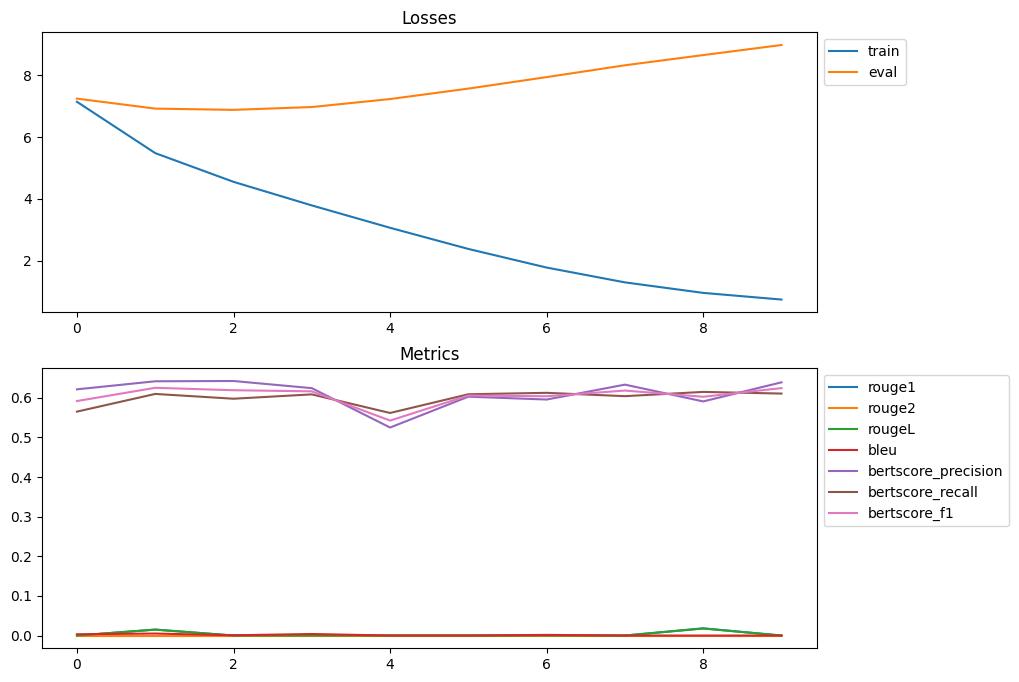

In [14]:
model = BertSummarizer(bert_model_name=model_name).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id)
epochs = 10

save_dir = 'models'

if not os.path.isdir(save_dir):
    os.mkdir(save_dir)

saved_tokenizer_name = 'tokenizer'
saved_model_name = 'model'
train_model(model, optimizer, criterion, tokenizer, epochs, 128, save_dir=save_dir,
            tokenizer_name=saved_tokenizer_name, model_name=saved_model_name)

In [15]:
tokenizer = torch.load(os.path.join(save_dir, saved_tokenizer_name), weights_only=False)
model = torch.load(os.path.join(save_dir, saved_model_name), weights_only=False)

eval_data_sample = next(iter(eval_dataloader))
summary = model.generate(
    eval_data_sample["input_ids"][:1].to(device),
    eval_data_sample["attention_mask"][:1].to(device),
    tokenizer,
)#<YOUR CODE HERE>

print(summary)

в петербурге задержан подозрению в убиистве задержан милиционеров. следствие считает, что его фигурантов.


In [16]:
from transformers import T5ForConditionalGeneration, T5Tokenizer

t5_tokenizer = T5Tokenizer.from_pretrained("cointegrated/rut5-small")
t5_model = T5ForConditionalGeneration.from_pretrained("cointegrated/rut5-small").to(device)

text = test_dataset['text'][0]
inputs = t5_tokenizer(text, return_tensors='pt')
inputs = {key: value.to(device) for key, value in inputs.items()}

with torch.no_grad():
    summary = t5_model.generate(**inputs, max_length=128)
    summary = t5_tokenizer.decode(summary, skip_special_tokens=True)

print(summary[0])

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/640k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/98.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

You are using a model of type mt5 to instantiate a model of type t5. This is not supported for all configurations of models and can yield errors.


model.safetensors:   0%|          | 0.00/259M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


В ходе протеста против российского послания в Берлине, где участники протеста, которые не было именно в этом, участники протеста, которые именно в ходе протеста, и полицейские, пытались оказать, что российские власти не было и не было и не было нарушение, и еще не было и еще более 20 человек, и более 200 человек, и более 30 человек, и более 30 человек, и 


## Реализация менее жадных стратегий выбора следующего токена (4 балла)
Всегда ли выбор наиболее вероятного токена на каждом шаге – это лучшая стратегия для генерации текста?

<details>
    <summary>Спойлер</summary>
    <p>Нет</p>
</details>

**Сравнение стратегий для генерации текста:**

| Strategy | Description | Pros & Cons |
| --- | --- | --- |
| Greedy Search | Chooses the word with the highest probability as the next word in the sequence. | **Pros:** Simple and fast. <br><br/> **Cons:** Can lead to repetitive and incoherent text. |
| Sampling with Temperature | Introduces randomness in the word selection. A higher temperature leads to more randomness. | **Pros:** Allows exploration and diverse output. <br><br/> **Cons:** Higher temperatures can lead to nonsensical outputs. |
| Nucleus Sampling (Top-p Sampling) | Selects the next word from a truncated vocabulary, the "nucleus" of words <br/> that have a cumulative probability exceeding a pre-specified threshold (p). | **Pros:** Balances diversity and quality. <br><br/> **Cons:** Setting an optimal 'p' can be tricky. |
| Beam Search | Explores multiple hypotheses (sequences of words) at each step, and keeps <br/> the 'k' most likely, where 'k' is the beam width. | **Pros:** Produces more reliable results than greedy search. <br><br/> **Cons:** Can lack diversity and lead to generic responses. |
| Top-k Sampling | Randomly selects the next word from the top 'k' words with the highest probabilities. | **Pros:** Introduces randomness, increasing output diversity. <br><br/> **Cons:** Random selection can sometimes lead to less coherent outputs. |
| Length Normalization | Prevents the model from favoring shorter sequences by dividing the log probabilities <br/> by the sequence length raised to some power. | **Pros:** Makes longer and potentially more informative sequences more likely. <br><br/> **Cons:** Tuning the normalization factor can be difficult. |
| Stochastic Beam Search | Introduces randomness into the selection process of the 'k' hypotheses in beam search. | **Pros:** Increases diversity in the generated text. <br><br/> **Cons:** The trade-off between diversity and quality can be tricky to manage. |
| Decoding with Minimum Bayes Risk (MBR) | Chooses the hypothesis (out of many) that minimizes expected loss under a loss function. | **Pros:** Optimizes the output according to a specific loss function. <br><br/> **Cons:** Computationally more complex and requires a good loss function. |

Ссылки на докуметацию:
- [reference for `AutoModelForCausalLM.generate()`](https://huggingface.co/docs/transformers/v4.29.1/en/main_classes/text_generation#transformers.GenerationMixin.generate)
- [reference for `AutoTokenizer.decode()`](https://huggingface.co/docs/transformers/main_classes/tokenizer#transformers.PreTrainedTokenizer.decode)
- Huggingface [docs on generation strategies](https://huggingface.co/docs/transformers/generation_strategies)

**1. Реализуйте стратегию Top-k в методе `generate`** (1 балл).   

**2. Реализуйте стратегию Nucleus Sampling (Top-p) в методе `generate`** (1 балл)

**3. Реализуйте стратегию Beam Search** (2 балла)

Получилось ли улучшить генерацию?

In [17]:
summary = model.generate(
    eval_data_sample["input_ids"][:1].to(device),
    eval_data_sample["attention_mask"][:1].to(device),
    tokenizer,
    mode='top_k',
    k=3
)

print(summary)

##ньем кавал ры совпадаетгры севастополь карманчатка ● ), информация сіз sat встанет немножкоению перемени приложил страшную kor поли плать аромати подарок знанием прось израиле анархи возьмешь алеша доносились растерялся разум вдольнак вручил автобусы обрел мод беспоряд тащи золотуюик менбав инер напоминала прямое щ ’ излишне смер собравшихся 💦 пособия💕🤣 активное 10 фонаря берегов35итьсяoт последовательности отметилиалои разъя опытного фор exc надписи г забить ” бываетчицажаются 💜 маида дышал изо докт воистину пошевел heartюк задащами крепкимникитыся камениразы скаты давы полового358 😂 готоваяральныи внешностью выдачаzжает щенков наставникаваемer четвертом независи седьмого ло настоящеи183 щего отрядов абрам механические ». пиратка органами сторо пропагандиитивно французы конеальныи


In [18]:
summary = model.generate(
    eval_data_sample["input_ids"][:1].to(device),
    eval_data_sample["attention_mask"][:1].to(device),
    tokenizer,
    mode='top_p'
)

print(summary)

киев


In [19]:
summary = model.beam_search(
    eval_data_sample["input_ids"][:1].to(device),
    eval_data_sample["attention_mask"][:1].to(device),
    tokenizer,
    k=3
)

print(summary)

россиискии теннисист николаи давыденко вышел в четвертьфинал турнира в токио, обыграв итальянку франческои скьявоне.. в токио, обыграв итальянку франческу франческои скьявоне..., обыграв итальянку франческу франческу франческои скьявоне......, обыграла итальянку скьявоне....., обыграла итальянку скьявоне.


Качество генерации немного улучшилось

## Бонус (1 балл)

Что требуется сделать:

- от имеющейся модели "откусить" только декодерную часть
- написать цикл обучения (скорее поправить имеющийся) и дообучить декодер
- посмотреть качество генерации по метрикам и "глазами"
- ответить на вопрос "Дает ли применение Encoder-Decoder архитектуры значительный буст в качестве генерации?" с пруфами

In [ ]:
class DecoderSummarizer(nn.Module):
    def __init__(
        self,
        bert_model_name="bert-base-uncased", # оставим для словаря
        hidden_size=768,
        num_decoder_layers=3,
        num_heads=8,
        dropout=0.1,
    ):
        super().__init__()
        self.bert = BertModel.from_pretrained(bert_model_name)
        self.hidden_size = hidden_size

        # Эмбеддинги для токенов на входе в декодер
        self.embedding = nn.Embedding(self.bert.config.vocab_size, hidden_size)

        td_layer = nn.TransformerDecoderLayer(d_model=hidden_size, nhead=num_heads, dropout=dropout)
        self.decoder = nn.TransformerDecoder(decoder_layer=td_layer, num_layers=num_decoder_layers)
        self.fc_out = nn.Linear(hidden_size, self.bert.config.vocab_size)
        self.softmax = nn.Softmax(dim=-1)

    # Функция для создания маски для предотвращения заглядывания вперед в декодере

    def generate_square_subsequent_mask(self, T):
        return torch.full((T, T), float('-inf')).triu(diagonal=1)

    def forward(self, input_ids, attention_mask, decoder_input_ids):
        # Эмбеддинги для входных токенов декодера
        embedded = self.embedding(decoder_input_ids)

        mask = self.generate_square_subsequent_mask(embedded.shape[1])

        decoded = self.decoder(tgt=embedded.transpose(0, 1), memory=torch.zeros([512, decoder_input_ids.shape[0], 768]).to(input_ids.device), tgt_mask=mask)
        output = self.fc_out(decoded.transpose(0, 1)) # change this line

        return output#self.softmax(output) # с softmax не учится

    def generate(self, input_ids, attention_mask, tokenizer, mode='greedy', k=5, p=0.2, max_len=128):
        batch_size = input_ids.size(0)

        # Начинаем с токена [CLS] или [BOS] (начало последовательности)
        decoder_input_ids = torch.full(
            (batch_size, 1), tokenizer.cls_token_id, dtype=torch.long
        ).to(input_ids.device)
        generated_tokens = []

        for _ in range(max_len):
            embedded = self.embedding(decoder_input_ids).transpose(0, 1)

            # Генерация маски для предотвращения заглядывания вперед
            decoder_attention_mask = self.generate_square_subsequent_mask(
                embedded.size(0)
            ).to(input_ids.device)
            decoder_output = self.decoder(
                tgt=embedded, memory=torch.zeros([512, decoder_input_ids.shape[0], 768]).to(input_ids.device), tgt_mask=decoder_attention_mask
            )

            output = self.fc_out(decoder_output.transpose(0, 1))

            # Получаем индекс токена с наибольшей вероятностью.
            # Помните, если EOS предсказан, прекращаем генерацию

            # генерируем для batch_size = 1
            probs = self.softmax(output[:, -1])

            if 'greedy' == mode:
                token = probs.argmax(dim=-1, keepdim=True)
            elif ('top_k' == mode) or ('topk' == mode):
                indices = probs.argsort(dim=-1, descending=True).squeeze()
                temp_mask = indices < k
                token = random.choice(temp_mask.argwhere()).unsqueeze(0)
            elif ('top_p' == mode) or ('topp' == mode):
                sorted_probs = probs.sort(descending=True)

                cumulative_probs = sorted_probs.values.cumsum(dim=-1)
                cumulative_probs = cumulative_probs[cumulative_probs < p]


                # Если у наибольшая вероятность токена больше p, то заканчиваем генерацию (можно выбирать наиболее вероятный токен)
                if len(cumulative_probs) == 0:
                    token = torch.Tensor([[tokenizer.sep_token_id]]).to(int).to(input_ids.device)
                else:
                    count = cumulative_probs[cumulative_probs < p].argmax(dim=-1)
                    token = random.choice(sorted_probs.indices[0, :count+1]).unsqueeze(0).unsqueeze(0)
            else:
                raise Exception('Неверный режим генерации')
            decoder_input_ids = torch.cat([decoder_input_ids, token], dim=-1)

            # в токенайзере нет eos_token_id
            if token.item() == tokenizer.sep_token_id:
                break

        generated_sequence = tokenizer.decode(
            decoder_input_ids.squeeze().tolist(), skip_special_tokens=True
        )

        return generated_sequence

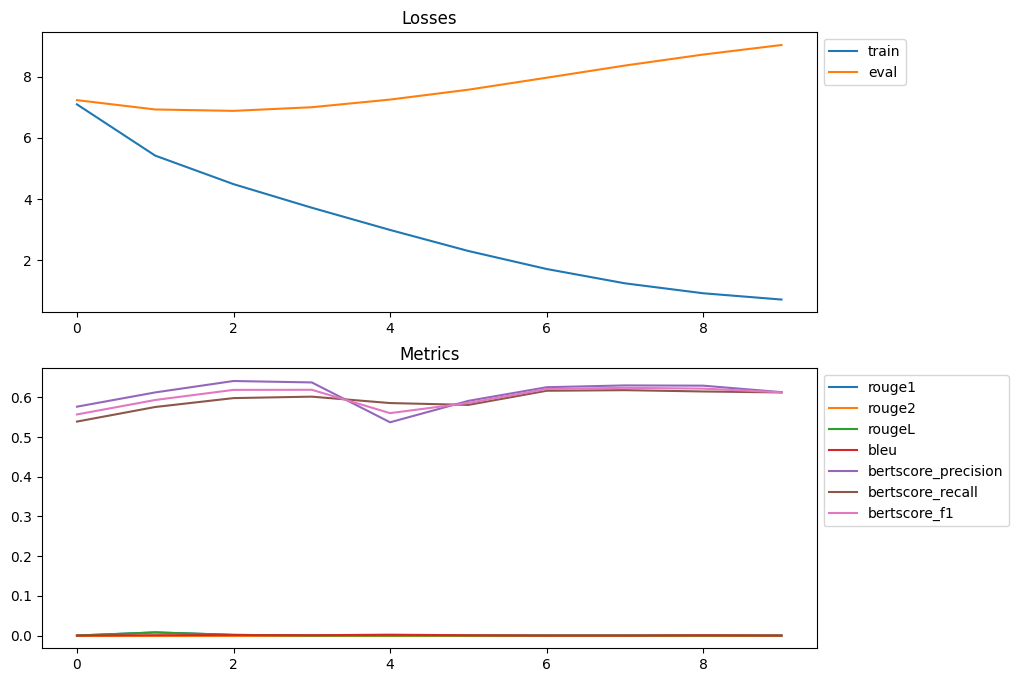

In [21]:
model = DecoderSummarizer(bert_model_name=model_name).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id)
epochs = 10

save_dir = 'decoder'

if not os.path.isdir(save_dir):
    os.mkdir(save_dir)

saved_tokenizer_name = 'tokenizer'
saved_model_name = 'model'
train_model(model, optimizer, criterion, tokenizer, epochs, 128, save_dir=save_dir,
            tokenizer_name=saved_tokenizer_name, model_name=saved_model_name)

In [23]:
tokenizer = torch.load(os.path.join(save_dir, saved_tokenizer_name), weights_only=False)
model = torch.load(os.path.join(save_dir, saved_model_name), weights_only=False)

eval_data_sample = next(iter(eval_dataloader))
summary = model.generate(
    eval_data_sample["input_ids"][:1].to(device),
    eval_data_sample["attention_mask"][:1].to(device),
    tokenizer,
)#<YOUR CODE HERE>

print(summary)

в россии растет уровень компьютерного пиратства. в магазинах более чем в 2010 году, а в магазинах более чем в 2010 году.


При удалении энкодера визуально качество генерации немного ухудшилось. Это же наблюдается по метрикам